# SYS5185 Parking Triage Optimization Project
 **Group 4**

Nouf Almudlej

### 1- Installing required requirements

In [1]:
!pip install -U ultralytics

In [2]:
from ultralytics import YOLO
import os
import json
import yaml

#print("Ultralytics imported successfully")

In [3]:
model = YOLO("yolov8n.pt")
#print(model)

In [4]:
import os
os.getcwd()

'D:\\SYS5185\\Project\\Parking Triage Project'

### 2- Importing the Dataset

In [5]:
!pip install datasets

In [6]:
from datasets import load_dataset

dataset = load_dataset("backseollgi/parking_dataset", "carpk")

C:\Users\jhied012\anaconda3\envs\datasci_project\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
sample = dataset["train"][0]
print(sample)
print(dataset)

{'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=1280x720 at 0x1EDA04C6490>, 'bboxes': [[766, 133, 804, 217], [766, 228, 801, 311], [758, 358, 793, 439], [750, 467, 786, 529], [755, 534, 789, 613], [542, 387, 619, 427], [555, 433, 628, 468], [553, 473, 630, 509], [544, 513, 619, 548], [542, 552, 612, 588], [530, 593, 609, 628], [543, 630, 611, 668], [559, 671, 619, 706], [459, 330, 534, 371], [344, 183, 419, 225], [233, 215, 310, 262], [233, 258, 315, 310], [234, 301, 305, 359], [220, 343, 295, 395], [221, 391, 296, 449], [213, 440, 295, 490], [218, 487, 295, 536], [217, 530, 301, 582], [208, 575, 293, 628], [216, 625, 296, 675], [214, 671, 289, 717], [388, 419, 463, 468], [390, 466, 458, 511], [367, 509, 443, 555], [375, 551, 447, 594], [373, 664, 446, 710]], 'labels': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]}
DatasetDict({
    train: Dataset({
        features: ['image', 'bboxes', 'labels'],
        num_rows: 989
    

### 3- Converting to YOLO

In [8]:
import os

base_dir = "parking_yolo"
os.makedirs(os.path.join(base_dir, "images", "train"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "images", "val"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "labels", "train"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "labels", "val"), exist_ok=True)

print("Folders created successfully")

Folders created successfully


In [9]:
def convert_to_yolo(box, img_width, img_height):
    x_min, y_min, x_max, y_max = box

    x_center = ((x_min + x_max) / 2) / img_width
    y_center = ((y_min + y_max) / 2) / img_height
    width = (x_max - x_min) / img_width
    height = (y_max - y_min) / img_height

    return x_center, y_center, width, height

In [10]:
train_data = dataset["train"]

In [11]:
for i, sample in enumerate(train_data):
    image = sample["image"]
    bboxes = sample["bboxes"]
    labels = sample["labels"]

    img_width, img_height = image.size

    image_filename = f"train_{i}.jpg"
    label_filename = f"train_{i}.txt"

    image_path = os.path.join(base_dir, "images", "train", image_filename)
    label_path = os.path.join(base_dir, "labels", "train", label_filename)

    image.save(image_path)

    with open(label_path, "w") as f:
        for box, label in zip(bboxes, labels):
            x_center, y_center, width, height = convert_to_yolo(box, img_width, img_height)
            f.write(f"{label} {x_center} {y_center} {width} {height}\n")

print("Training data converted successfully")

In [12]:
test_data = dataset["test"]

In [13]:
for i, sample in enumerate(test_data):
    image = sample["image"]
    bboxes = sample["bboxes"]
    labels = sample["labels"]

    img_width, img_height = image.size

    image_filename = f"val_{i}.jpg"
    label_filename = f"val_{i}.txt"

    image_path = os.path.join(base_dir, "images", "val", image_filename)
    label_path = os.path.join(base_dir, "labels", "val", label_filename)

    image.save(image_path)

    with open(label_path, "w") as f:
        for box, label in zip(bboxes, labels):
            x_center, y_center, width, height = convert_to_yolo(box, img_width, img_height)
            f.write(f"{label} {x_center} {y_center} {width} {height}\n")

print("Validation data converted successfully")

In [14]:
data_yaml = """
path: parking_yolo
train: images/train
val: images/val

nc: 1
names: ['car']
"""

with open("parking_yolo/data.yaml", "w") as f:
    f.write(data_yaml)

print("data.yaml file created successfully")

data.yaml file created successfully


In [15]:
label_example = os.path.join(base_dir, "labels", "train", os.listdir(os.path.join(base_dir, "labels", "train"))[0])

with open(label_example, "r") as f:
    print(f.read())

0 0.61328125 0.24305555555555555 0.0296875 0.11666666666666667
0 0.612109375 0.37430555555555556 0.02734375 0.11527777777777778
0 0.605859375 0.5534722222222223 0.02734375 0.1125
0 0.6 0.6916666666666667 0.028125 0.08611111111111111
0 0.603125 0.7965277777777777 0.0265625 0.10972222222222222
0 0.453515625 0.5652777777777778 0.06015625 0.05555555555555555
0 0.462109375 0.6256944444444444 0.05703125 0.04861111111111111
0 0.462109375 0.6819444444444445 0.06015625 0.05
0 0.454296875 0.7368055555555556 0.05859375 0.04861111111111111
0 0.45078125 0.7916666666666666 0.0546875 0.05
0 0.444921875 0.8479166666666667 0.06171875 0.04861111111111111
0 0.45078125 0.9013888888888889 0.053125 0.05277777777777778
0 0.46015625 0.95625 0.046875 0.04861111111111111
0 0.387890625 0.48680555555555555 0.05859375 0.05694444444444444
0 0.298046875 0.2833333333333333 0.05859375 0.058333333333333334
0 0.212109375 0.33125 0.06015625 0.06527777777777778
0 0.2140625 0.39444444444444443 0.0640625 0.07222222222222222

In [16]:
print("Train images:", len(os.listdir(os.path.join(base_dir, "images", "train"))))
print("Train labels:", len(os.listdir(os.path.join(base_dir, "labels", "train"))))
print("Val images:", len(os.listdir(os.path.join(base_dir, "images", "val"))))
print("Val labels:", len(os.listdir(os.path.join(base_dir, "labels", "val"))))

Train images: 989
Train labels: 989
Val images: 459
Val labels: 459


# PART 1: Detecting Cars

### 1- Train the model to detect objects (Cars)

In [17]:
results = model.train(
    data="parking_yolo/data.yaml",
    epochs=5,
    imgsz=416,
    batch=4,
    name="parking_car_detector"
)

# #Note: since I am using CPU I had to train with limited epochs and batchs, Optimally we should train with 20 epochs and 8 batches at least.

interpret results

In [18]:
print(results)

In [19]:
model = YOLO("runs/detect/parking_car_detector/weights/best.pt")

results = model.predict(
    source="parking_yolo/images/val",
    save=True,
    conf=0.25
)

#note: to redue false positive (shadows), we should raise the conf.

### 2- Evaluate the model

In [20]:
from ultralytics import YOLO

model = YOLO("runs/detect/parking_car_detector/weights/best.pt")
metrics = model.val(data="parking_yolo/data.yaml")
print(metrics)

In [21]:
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

# PART 2: Detecting parking spots

### 1- Manually labeling parking spots

First we get the box size

In [22]:
i = 7
img_name = f"val_{i}.jpg"   #changable
pass

In [23]:
i = 7
img_name = f"val_{i}.jpg"  #changable
img_path = os.path.join("parking_yolo/images/val", img_name)

print(img_path)

parking_yolo/images/val\val_7.jpg


In [24]:
from ultralytics import YOLO

model = YOLO("runs/detect/parking_car_detector/weights/best.pt")

result = model.predict(source=img_path, conf=0.5, save=False)[0]


image 1/1 D:\SYS5185\Project\Parking Triage Project\parking_yolo\images\val\val_7.jpg: 256x416 122 cars, 127.4ms
Speed: 5.5ms preprocess, 127.4ms inference, 17.5ms postprocess per image at shape (1, 3, 256, 416)


In [25]:
car_boxes = result.boxes.xyxy.cpu().numpy()
print(car_boxes[:5])
print("Number of detected cars:", len(car_boxes))

[[     821.89      478.65      859.87      552.65]
 [     1095.6      289.81      1130.3      369.72]
 [     302.28      300.32      337.85      378.53]
 [     420.63      288.85      462.91      375.78]
 [     413.07      571.63      449.48       651.7]]
Number of detected cars: 122


In [26]:
import numpy as np

widths = []
heights = []

for box in car_boxes:
    x1, y1, x2, y2 = box
    widths.append(x2 - x1)
    heights.append(y2 - y1)

avg_w = int(np.mean(widths))
avg_h = int(np.mean(heights))

print("Average width:", avg_w)
print("Average height:", avg_h)

Average width: 39
Average height: 76


Counting the number of boxes (Cars) in an image

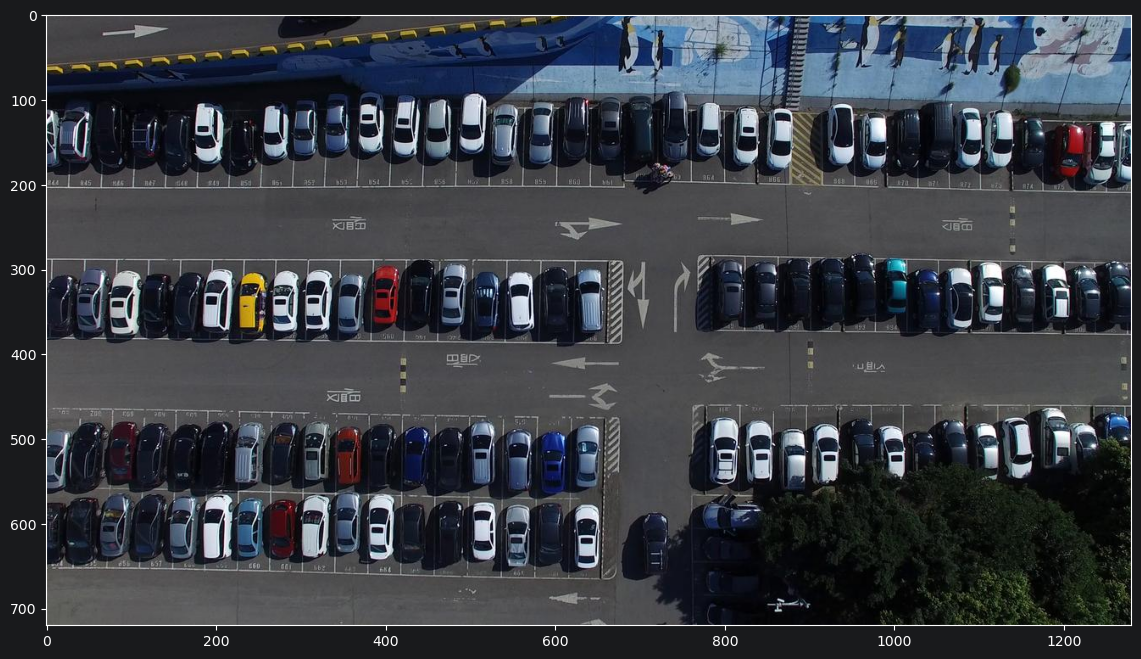

In [27]:
%matplotlib inline
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(img_rgb)
plt.axis("on")

plt.show()

Second we use the box size to locate the center of the box (car)

In [28]:
spot_center = (1100, 470)

x_center, y_center = spot_center

parking_spots = []

# create vertical row of spots
for i in range(-2, 3):  # 5 spots
    y = y_center + i * avg_h

    x1 = int(x_center - avg_w / 2)
    y1 = int(y - avg_h / 2)
    x2 = int(x_center + avg_w / 2)
    y2 = int(y + avg_h / 2)

    parking_spots.append([x1, y1, x2, y2])

print(parking_spots)

[[1080, 280, 1119, 356], [1080, 356, 1119, 432], [1080, 432, 1119, 508], [1080, 508, 1119, 584], [1080, 584, 1119, 660]]


Manual labelling of a sample

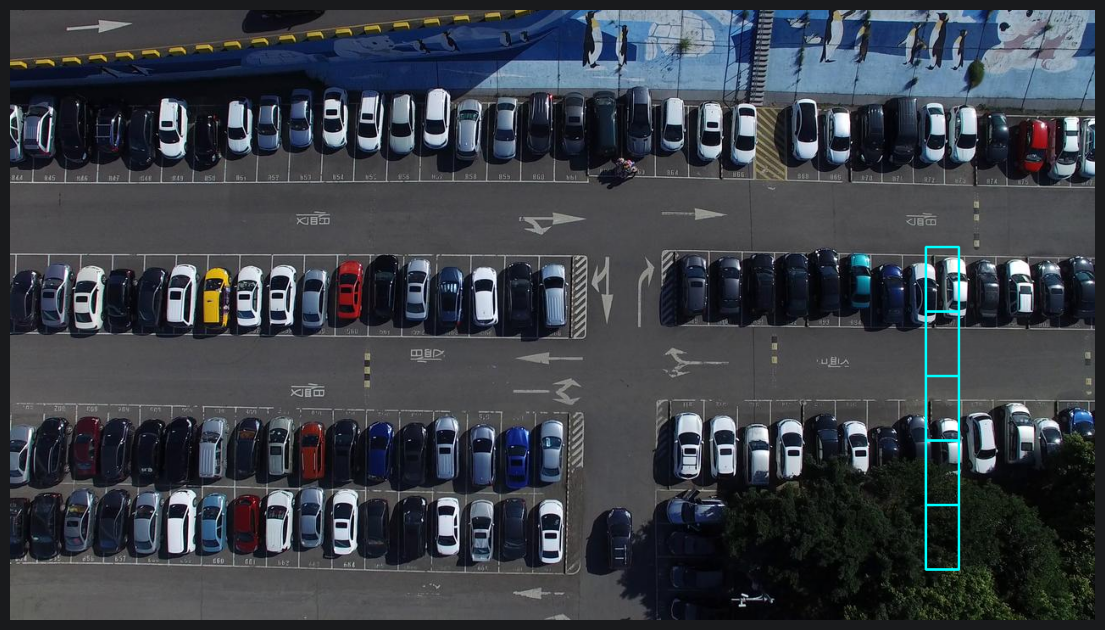

In [29]:
img = cv2.imread(img_path)

for spot in parking_spots:
    x1, y1, x2, y2 = map(int, spot)
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

### 2- Identifying the occupancy of sample spots

In [30]:
def overlap_ratio(spot, car):
    xA = max(spot[0], car[0])
    yA = max(spot[1], car[1])
    xB = min(spot[2], car[2])
    yB = min(spot[3], car[3])

    inter_w = max(0, xB - xA)
    inter_h = max(0, yB - yA)
    inter_area = inter_w * inter_h

    spot_area = max(0, spot[2] - spot[0]) * max(0, spot[3] - spot[1])

    if spot_area == 0:
        return 0

    return inter_area / spot_area

In [31]:
def point_in_box(point, box):
    px, py = point
    x1, y1, x2, y2 = box
    return x1 <= px <= x2 and y1 <= py <= y2

In [32]:
occupied_flags = []

for spot in parking_spots:
    occupied = False
    for car in car_boxes:
        x1, y1, x2, y2 = car
        car_center = ((x1 + x2) / 2, (y1 + y2) / 2)

        if point_in_box(car_center, spot):
            occupied = True
            break

    occupied_flags.append(occupied)

print(occupied_flags)

[True, False, False, True, False]


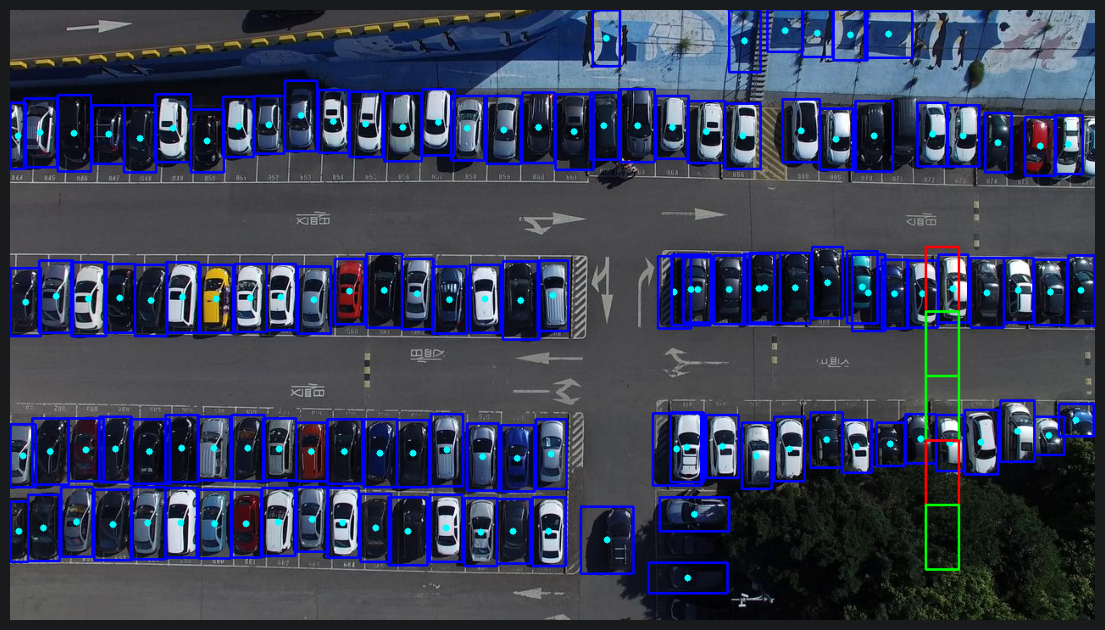

In [33]:
img = cv2.imread(img_path)

# draw car boxes in blue
for car in car_boxes:
    x1, y1, x2, y2 = map(int, car)
    cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    cx = int((x1 + x2) / 2)
    cy = int((y1 + y2) / 2)
    cv2.circle(img, (cx, cy), 4, (255, 255, 0), -1)

# draw parking spots
for spot, occ in zip(parking_spots, occupied_flags):
    x1, y1, x2, y2 = map(int, spot)
    color = (0, 0, 255) if occ else (0, 255, 0)
    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()

### 3- Evaluate the model

In [34]:
def predict_spot_occupancy(car_boxes, parking_spots):
    """
    Predict whether each parking spot is occupied (1) or empty (0)
    based on whether the center of a detected car falls inside the spot.
    """
    predicted_labels = []

    for spot in parking_spots:
        occupied = False

        for car in car_boxes:
            x1, y1, x2, y2 = car
            car_center = ((x1 + x2) / 2, (y1 + y2) / 2)

            if point_in_box(car_center, spot):
                occupied = True
                break

        predicted_labels.append(1 if occupied else 0)

    return predicted_labels

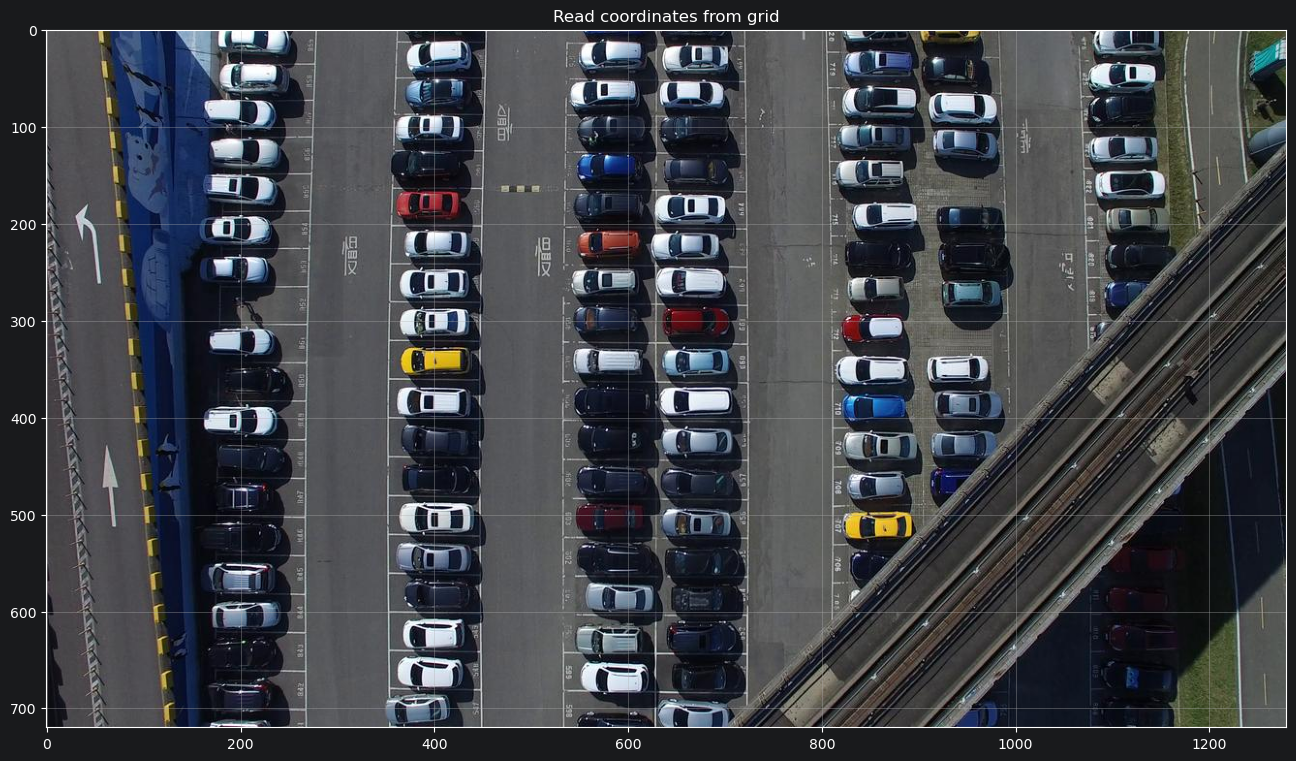

In [35]:
#to get coordinates for manually labelled images
import cv2
import matplotlib.pyplot as plt
img_path = os.path.join("parking_yolo/images/val", "val_8.jpg")
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(16, 10))
plt.imshow(img_rgb)


plt.grid(True)
plt.title("Read coordinates from grid")
plt.show()

In [36]:
manually_trained_data = {
    "val_458.jpg": {
        "spots": [
        [250, 150, 330, 180],  # 1st right
        [275, 125, 360, 155],  # 2nd
        [300, 100, 390, 140],  # 3rd
        [330, 65, 420, 100],  # 4th
        [370, 40, 450, 75],  # 5th
        ],
        "labels": [1, 1, 1, 1, 0]
    },

    "val_2.jpg": {
        "spots": [
            [930, 200, 970, 280],
            [970, 200, 1010, 280],
            [1010, 200, 1050, 300],
            [1050, 210, 1090, 300]
        ],
        "labels": [1, 0, 1, 1]
    },
    "val_6.jpg": {
        "spots": [
            [710, 310, 740, 400],
            [740, 300, 780, 400],
            [780, 300, 825, 400],
            [825, 300, 850, 400]
        ],
        "labels": [1, 0, 1, 1]
    },
    "val_8.jpg": {
        "spots": [
            [910, 370, 1000, 400],
            [910, 325, 1000, 370],
            [910, 290, 1000, 325],
            [910, 250, 1000, 290]
        ],
        "labels": [1, 1, 0, 1]
    }

}
#Note: I choose a sample of 4 random images

In [37]:
all_true = []
all_pred = []

for img_name, data in manually_trained_data.items():
    img_path = os.path.join("parking_yolo/images/val", img_name)

    result = model.predict(source=img_path, conf=0.5, save=False, verbose=False)[0]
    car_boxes = result.boxes.xyxy.cpu().numpy()

    predicted_labels = predict_spot_occupancy(car_boxes, data["spots"])
    true_labels = data["labels"]

    all_true.extend(true_labels)
    all_pred.extend(predicted_labels)

    print(f"Image: {img_name}")
    print("True labels:     ", true_labels)
    print("Predicted labels:", predicted_labels)
    print("-" * 50)

Image: val_458.jpg
True labels:      [1, 1, 1, 1, 0]
Predicted labels: [1, 1, 1, 1, 0]
--------------------------------------------------
Image: val_2.jpg
True labels:      [1, 0, 1, 1]
Predicted labels: [1, 0, 1, 1]
--------------------------------------------------
Image: val_6.jpg
True labels:      [1, 0, 1, 1]
Predicted labels: [1, 0, 1, 1]
--------------------------------------------------
Image: val_8.jpg
True labels:      [1, 1, 0, 1]
Predicted labels: [1, 1, 0, 1]
--------------------------------------------------


In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
acc = accuracy_score(all_true, all_pred)
prec = precision_score(all_true, all_pred, zero_division=0)
rec = recall_score(all_true, all_pred, zero_division=0)
f1 = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)

print("Occupancy Prediction Metrics")
print("Accuracy: ", acc)
print("Precision:", prec)
print("Recall:   ", rec)
print("F1-score: ", f1)
print("Confusion Matrix:")
print(cm)

Occupancy Prediction Metrics
Accuracy:  1.0
Precision: 1.0
Recall:    1.0
F1-score:  1.0
Confusion Matrix:
[[ 4  0]
 [ 0 13]]


### 4- Visulaiztion

In [39]:
def visualize_parking_prediction(img_name, spots, true_labels, predicted_labels, model, image_folder="parking_yolo/images/val"):
    img_path = os.path.join(image_folder, img_name)

    result = model.predict(source=img_path, conf=0.5, save=False, verbose=False)[0]
    car_boxes = result.boxes.xyxy.cpu().numpy()

    img = cv2.imread(img_path)

    # draw detected cars in blue
    for car in car_boxes:
        x1, y1, x2, y2 = map(int, car)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

        cx = int((x1 + x2) / 2)
        cy = int((y1 + y2) / 2)
        cv2.circle(img, (cx, cy), 4, (255, 255, 0), -1)

    # draw parking spots
    for spot, true_label, pred_label in zip(spots, true_labels, predicted_labels):
        x1, y1, x2, y2 = map(int, spot)

        if pred_label == 1:
            color = (0, 0, 255)   # red = predicted occupied
        else:
            color = (0, 255, 0)   # green = predicted empty

        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # optional text: T=true, P=pred
        text = f"T:{true_label} P:{pred_label}"
        cv2.putText(img, text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.45, color, 1)

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(14, 8))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

    return img, result

In [46]:
# Select image for visualization
img_name = "val_8.jpg"
spots = manually_trained_data[img_name]["spots"]
true_labels = manually_trained_data[img_name]["labels"]

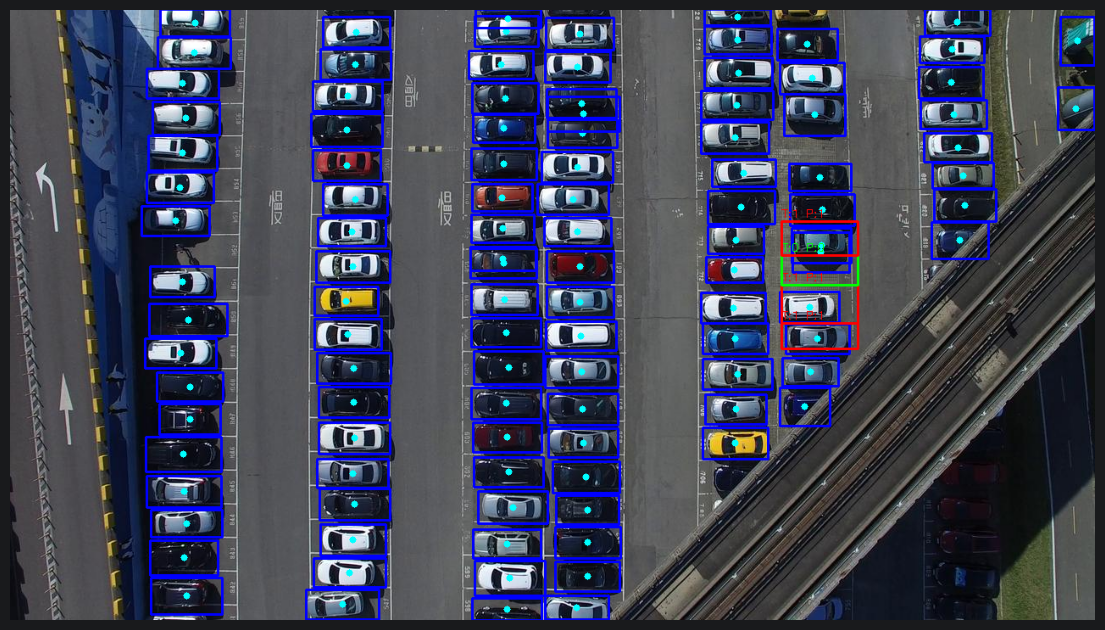

In [47]:
result = model.predict(source=os.path.join("parking_yolo/images/val", img_name), conf=0.5, save=False, verbose=False)[0]
car_boxes = result.boxes.xyxy.cpu().numpy()
predicted_labels = predict_spot_occupancy(car_boxes, spots)

final_img, final_res = visualize_parking_prediction(img_name, spots, true_labels, predicted_labels, model)

# Application: "Parking Triage"

Using the labels created, and manually setting an "entry" location (showing where the user would drive into the parking lot), we can provide drivers the location of a specific spot for them to use. This could be expanded to not only factor starting position, but also (non-exhaustively):
- Intended destination (closest entrance to specific shop in shopping mall, for instance)
- Specific needs (allowing users to select parameters such as Expectant Parent Spots, Accessible Parking, Electric Vehicle Charging, etc)

In [50]:
# Export the predicted data and visualize using custom Visualizer
import application.export_prediction as exporter

os.makedirs(f"outputs/{img_name[:-4]}", exist_ok=True)
output_path = os.path.join("outputs", img_name[:-4], "parking_data.json")

exporter.export_parking_prediction_json(img_name, car_boxes, spots, true_labels, predicted_labels, model, out_path=output_path)
print(output_path)

outputs\val_8\parking_data.json


In [51]:
import application.visualizer_lib as visualizer

img_path = os.path.join("parking_yolo/images/val", img_name)
tagged_image = visualizer.external_visualize(
    img_path=img_path,
    point_path=output_path,
    show_occupancy_rate=True,
    show_closest_vacancy=True
)

try:
    print(f"Size of image: {tagged_image.shape[1]}x{tagged_image.shape[0]}")
    cv2.imshow("Parking Lot Visualization", tagged_image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
except KeyboardInterrupt or InterruptedError:
    cv2.destroyAllWindows()

Size of image: 1280x720
